Customer Segmentation w/ PySpark

In [1]:
# Install pyspark if needed
# %pip install pyspark

In [2]:
#import the necessary libraries
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot
%matplotlib inline

In [3]:
# Create the Spark Session, the entry point for all Spark DataFrame operations
spark = (
    SparkSession.builder
    .appName("Online Retail PySpark Analysis")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/31 19:45:19 WARN Utils: Your hostname, Yao-FudeMacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.195 instead (on interface en0)
26/07/31 19:45:19 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/07/31 19:45:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
# Import dataset via Spark
pd.set_option('display.float_format', lambda x: '%.2f' % x)
data = spark.read.csv('OnlineRetail.csv', header=True, inferSchema=True)

# Check types
data.printSchema()

# See rows
data.show(5)

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|  

## Data Preprocessing

In [5]:
# Check duplicates
duplicate_count = data.count() - data.dropDuplicates().count()
print(f"Duplicated Items in Dataset: {duplicate_count}")

Duplicated Items in Dataset: 5268


In [6]:
# Remove duplicates
data = data.dropDuplicates()
duplicate_count = data.count() - data.dropDuplicates().count()
print(f"Duplicated Items in Dataset after Dropping: {duplicate_count}")

Duplicated Items in Dataset after Dropping: 0


In [7]:
# Check missing values
missing_counts = data.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in data.columns])
missing_counts.show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|       1454|       0|          0|        0|    135037|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



In [8]:
# Creates a list of unique invoice No. with Null Customer ID
invoice_list = data.filter(F.col('CustomerID').isNull()).select('InvoiceNo').rdd.flatMap(lambda x: x).collect()

In [9]:
# Verify the Invoice List
print("InvoiceList: ", invoice_list[:10])
print("Invoice Size:", len(invoice_list))

InvoiceList:  ['536414', '536544', '536544', '536544', '536544', '536544', '536544', '536544', '536544', '536544']
Invoice Size: 135037


In [10]:
# Cancelled items
result = data.filter(F.col('InvoiceNo').startswith('C')).count()
result

9251

In [11]:
# Checking the number of records with Quantity Negative and Prices 0 or Vice versa
inconsistent_records = data.filter((F.col('Quantity') < 0) & (F.col('UnitPrice') == 0))
print(f"The number of records with Quantity Negative and Prices 0 or Vice versa : {inconsistent_records.count()}")

# Checking if Negative quantities are cancelled items
cancelled_items = inconsistent_records.filter(F.col('InvoiceNo').contains('C')).count()
print(f"Number of Negative Quantities due to Cancelled Items: {cancelled_items}")

# Checking for Records with Negative Unit Price
negative_prices = data.filter(F.col('UnitPrice') < 0).count()
print(f"The number of transactions with Negative Unit Price: {negative_prices}")

# Checking for Records with Unit Price 0
zero_price = data.filter(F.col('UnitPrice') == 0).count()
print(f"The number of transactions with Unit Price 0: {zero_price}")

The number of records with Quantity Negative and Prices 0 or Vice versa : 1336


Number of Negative Quantities due to Cancelled Items: 0


The number of transactions with Negative Unit Price: 2
The number of transactions with Unit Price 0: 2510


In [12]:
# Removing records with Null Customer ID
data = data.dropna(subset=['CustomerID'])
missing_counts = data.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in data.columns])
print("Remaining Missing Values:")
missing_counts.show()

Remaining Missing Values:


+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|          0|       0|          0|        0|         0|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



In [13]:
# Copy the dataset and convert CustomerID to int
rfm_train = data.withColumn('CustomerID', F.col('CustomerID').cast('int'))

In [14]:
# Count the number of missing values
missing_counts = rfm_train.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in rfm_train.columns])
missing_counts.show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|          0|       0|          0|        0|         0|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



In [15]:
## remove transactions with Cancelled Items.
placed = rfm_train.filter(~F.col('InvoiceNo').startswith('C'))

In [16]:
# Calculate total cost
placed = placed.withColumn('TotalCost', F.col('Quantity') * F.col('UnitPrice'))
placed.show(5)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+------------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|         TotalCost|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+------------------+
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|             20.34|
|   536367|    22623|BOX OF VINTAGE JI...|       3|12/1/2010 8:34|     4.95|     13047|United Kingdom|14.850000000000001|
|   536368|    22912|YELLOW COAT RACK ...|       3|12/1/2010 8:34|     4.95|     13047|United Kingdom|14.850000000000001|
|   536368|    22914|BLUE COAT RACK PA...|       3|12/1/2010 8:34|     4.95|     13047|United Kingdom|14.850000000000001|
|   536369|    21756|BATH BUILDING BLO...|       3|12/1/2010 8:35|     5.95|     13047|United Kingdom|             17.85|
+---------+---------+---

## Exploratory Data Analysis

In [17]:
# Find The Time Period of Transactions
# Need to convert to timestamp first
placed = placed.withColumn('InvoiceDate', F.try_to_timestamp(F.col('InvoiceDate'), F.lit('M/d/yyyy H:mm')))

In [18]:
# Check date range
date_range = placed.select(F.min('InvoiceDate').alias('oldest'), F.max('InvoiceDate').alias('latest')).first()
print(f"Oldest date is: {date_range['oldest']}")
print(f"Latest date is: {date_range['latest']}")

Oldest date is: 2010-12-01 08:26:00
Latest date is: 2011-12-09 12:50:00


## Order Density in Different Countries

In [19]:
# Display the proportion of order based on country
total_orders = placed.count()
proportions = (placed.groupBy('Country').count()
               .withColumn('proportion', F.round(F.col('count') / total_orders * 100, 1))
               .orderBy(F.desc('count')))
proportions.show(12)

+--------------+------+----------+
|       Country| count|proportion|
+--------------+------+----------+
|United Kingdom|349227|      88.9|
|       Germany|  9027|       2.3|
|        France|  8327|       2.1|
|          EIRE|  7228|       1.8|
|         Spain|  2480|       0.6|
|   Netherlands|  2363|       0.6|
|       Belgium|  2031|       0.5|
|   Switzerland|  1842|       0.5|
|      Portugal|  1453|       0.4|
|     Australia|  1184|       0.3|
|        Norway|  1072|       0.3|
|         Italy|   758|       0.2|
+--------------+------+----------+
only showing top 12 rows


/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


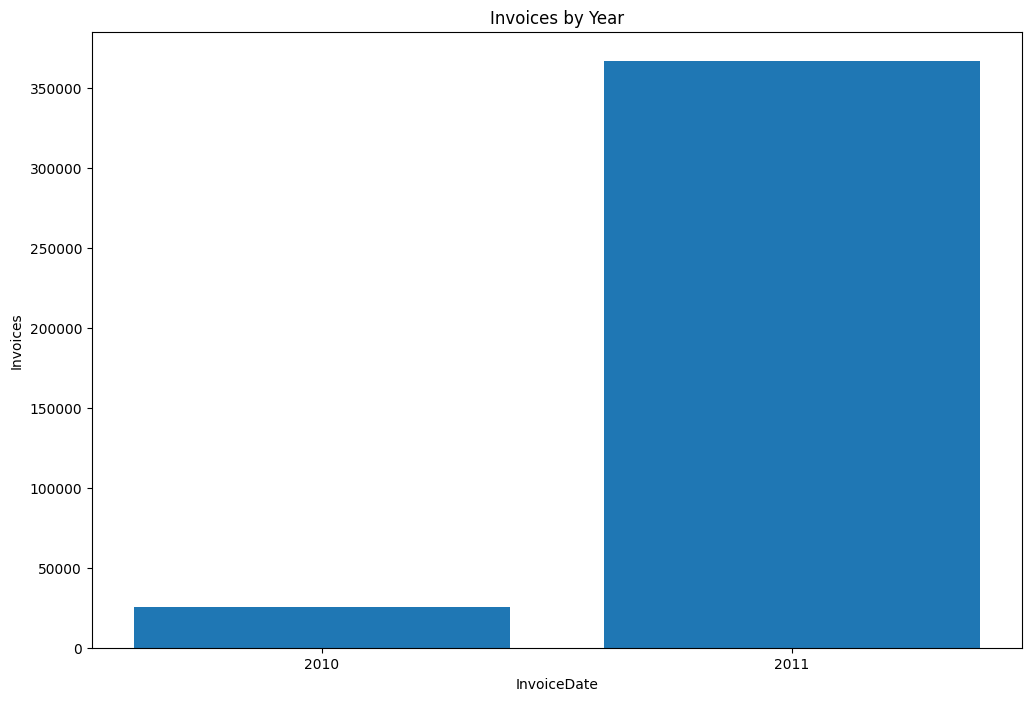

In [20]:
# Bar Graph comparing the number invoices by year
by_year = placed.groupBy(F.year('InvoiceDate').alias('Year')).count().orderBy('Year').toPandas()

plt.figure(figsize=(12, 8))
plt.bar(by_year['Year'].astype(str), by_year['count'])
plt.title('Invoices by Year')
plt.ylabel('Invoices')
plt.xlabel('InvoiceDate')
plt.show()

/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


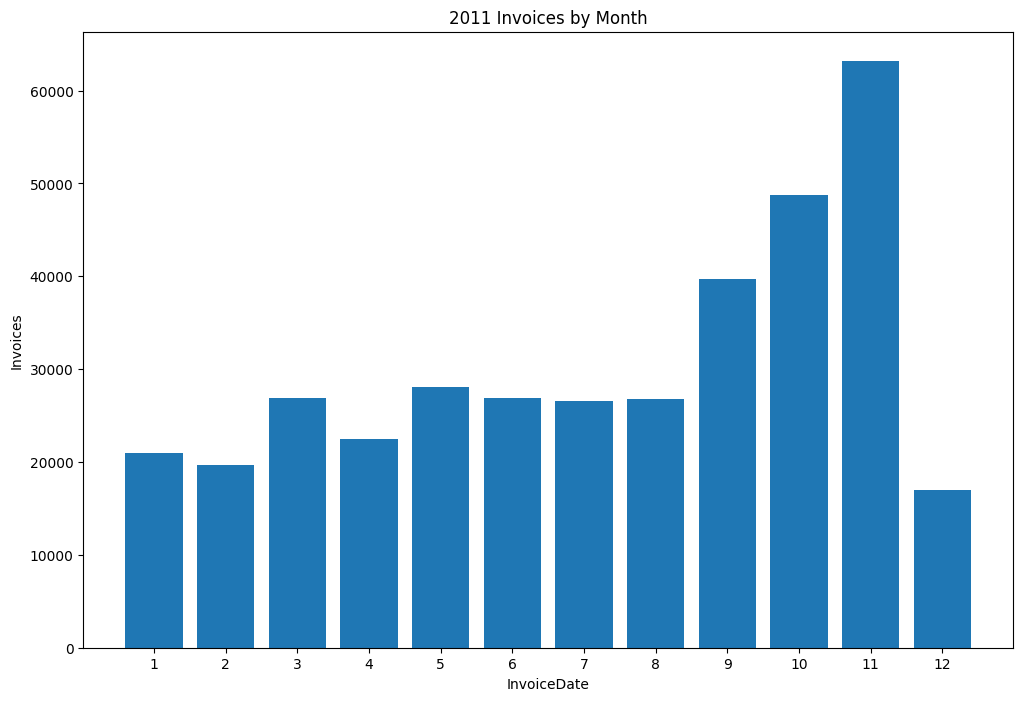

In [21]:
# Bar Graph comparing the number invoices by month in 2011
by_month_2011 = (placed.filter(F.year('InvoiceDate') == 2011)
                  .groupBy(F.month('InvoiceDate').alias('Month')).count()
                  .orderBy('Month').toPandas())

plt.figure(figsize=(12, 8))
plt.bar(by_month_2011['Month'].astype(str), by_month_2011['count'])
plt.title('2011 Invoices by Month')
plt.ylabel('Invoices')
plt.xlabel('InvoiceDate')
plt.show()

/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


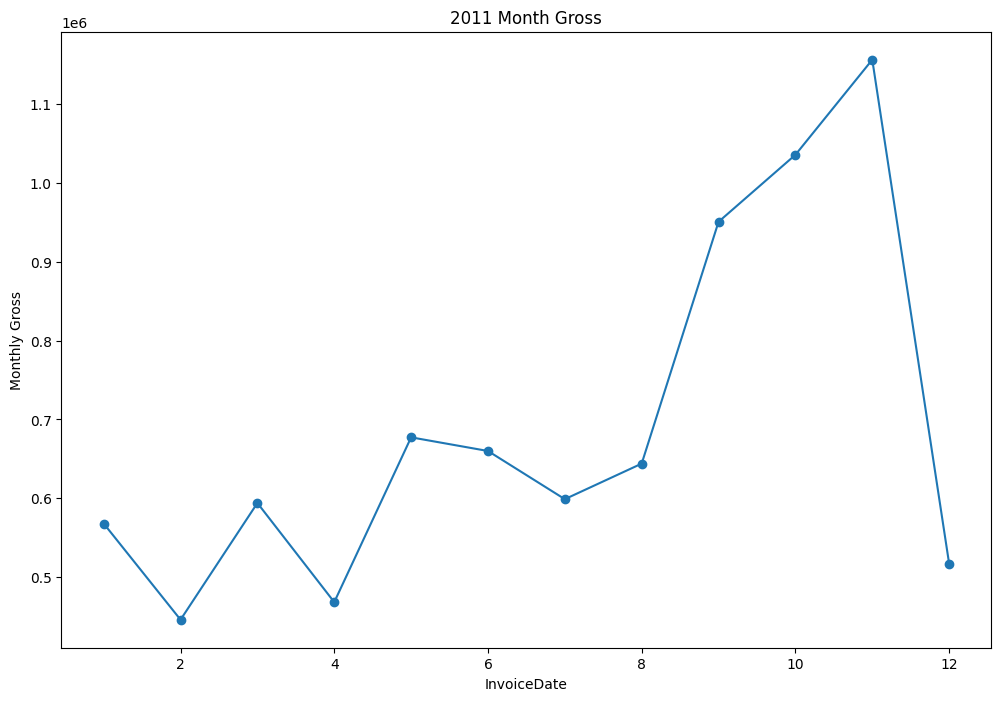

In [22]:
# Line Graph comparing the monthly gross rate in 2011
monthly_gross = (placed.filter(F.year('InvoiceDate') == 2011)
                  .groupBy(F.month('InvoiceDate').alias('Month')).agg(F.sum('TotalCost').alias('Gross'))
                  .orderBy('Month').toPandas())

plt.figure(figsize=(12, 8))
plt.plot(monthly_gross['Month'], monthly_gross['Gross'], marker='o')
plt.title('2011 Month Gross')
plt.ylabel('Monthly Gross')
plt.xlabel('InvoiceDate')
plt.show()

/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


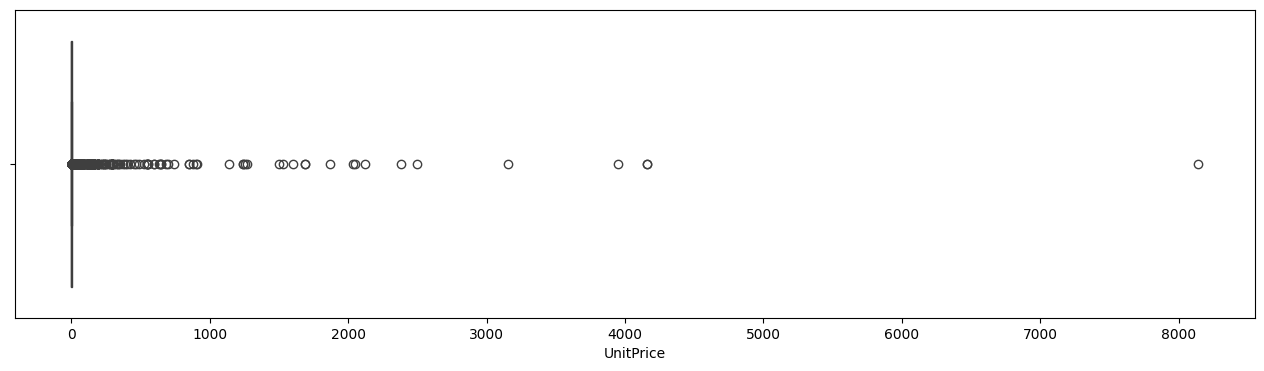

In [23]:
# Check unit price distributions
unit_price_pd = placed.select('UnitPrice').toPandas()

plt.figure(figsize=(16, 4))
sns.boxplot(x='UnitPrice', data=unit_price_pd, orient='h')
plt.show()

Unit Price is more concentrated in lower values of prices.

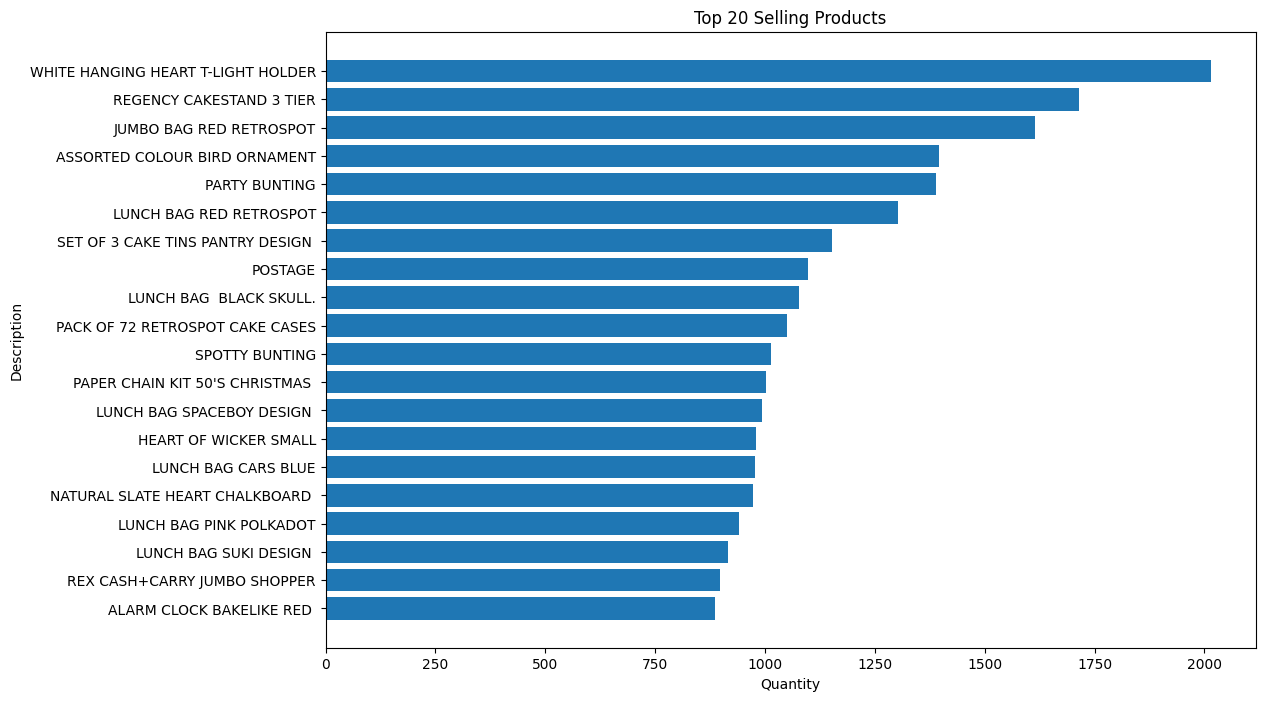

In [24]:
# Check top 20 selling products
# Group by Description, count occurrences, and sort by descending quantity
top_20 = (placed.groupBy('Description').count()
          .orderBy('count')
          .tail(20)) # Need to do this to reverse ordering
top_20 = pd.DataFrame(top_20, columns=['Description', 'count']).sort_values('count')

plt.figure(figsize=(12, 8))
plt.barh(top_20['Description'], top_20['count'])
plt.title('Top 20 Selling Products')
plt.ylabel('Description')
plt.xlabel('Quantity')
plt.show()

# Recency, Frequency, Monetary (RFM) ANALYSIS

In [25]:
# Print Latest date in the Order History
latest_date = placed.select(F.max('InvoiceDate')).first()[0]
print(latest_date)

2011-12-09 12:50:00


In [26]:
# One day beyond oldest date
current_date = '2011-12-10'

In [27]:
# Create Separate Column for Recency
recency = (placed.groupBy('CustomerID').agg(F.max('InvoiceDate').alias('Purchase_Date')))

In [28]:
# Calculate Recency based on purchase date and current date
recency = recency.withColumn('Recency', F.datediff(F.lit(current_date), F.col('Purchase_Date')))

# Display Recency
recency.show(5)

+----------+-------------------+-------+
|CustomerID|      Purchase_Date|Recency|
+----------+-------------------+-------+
|     17850|2010-12-02 15:27:00|    373|
|     17420|2011-10-20 14:52:00|     51|
|     15862|2011-12-01 13:28:00|      9|
|     14045|2011-08-22 15:27:00|    110|
|     13694|2011-12-06 09:32:00|      4|
+----------+-------------------+-------+
only showing top 5 rows


In [29]:
# Drop Date Columns which are not useful anymore.
recency = recency.drop('Purchase_Date')
recency.show(5)

+----------+-------+
|CustomerID|Recency|
+----------+-------+
|     17850|    373|
|     17420|     51|
|     15862|      9|
|     14045|    110|
|     13694|      4|
+----------+-------+
only showing top 5 rows


In [30]:
# Calculate Frequency based on Customer ID
frequency = (placed.dropDuplicates(['CustomerID', 'InvoiceNo'])
             .groupBy('CustomerID').agg(F.count('InvoiceNo').alias('Frequency')))
frequency.show(5)

+----------+---------+
|CustomerID|Frequency|
+----------+---------+
|     17420|        3|
|     17850|       34|
|     16552|        2|
|     15350|        1|
|     12921|       37|
+----------+---------+
only showing top 5 rows


In [31]:
# Calculate Monetary based on total cost per Customer
monetary = placed.groupBy('CustomerID').agg(F.sum('TotalCost').alias('Monetary'))
monetary.show(5)

+----------+-----------------+
|CustomerID|         Monetary|
+----------+-----------------+
|     17850|5391.210000000001|
|     17420|598.8299999999999|
|     15862|           832.88|
|     12921|         16587.09|
|     14496|           538.81|
+----------+-----------------+
only showing top 5 rows


In [32]:
# Combine Recency, Frequency and Monetary into a single table
rfm_table = recency.join(frequency, on='CustomerID').join(monetary, on='CustomerID')
rfm_table.show(5)

+----------+-------+---------+-----------------+
|CustomerID|Recency|Frequency|         Monetary|
+----------+-------+---------+-----------------+
|     17420|     51|        3|598.8299999999999|
|     17850|    373|       34|5391.210000000001|
|     16552|    243|        2|           379.73|
|     15350|    374|        1|           115.65|
|     12921|     10|       37|         16587.09|
+----------+-------+---------+-----------------+
only showing top 5 rows


In [33]:
# Distribution plot for Recency, Frequency, and Monetary
rfm_pd = rfm_table.toPandas().set_index('CustomerID')

def dist_plot(data, measure):
    fig = plt.figure(figsize=(20, 7))

    # Get the fitted parameters used by the function
    (mu, sigma) = norm.fit(data)

    # Kernel Density plot
    fig1 = fig.add_subplot(121)
    sns.histplot(data, kde=True, stat='density', ax=fig1)
    fig1.set_title(measure + ' Distribution ( mu = {:.2f} and sigma = {:.2f} )'.format(mu, sigma), loc='center')
    fig1.set_xlabel(measure)
    fig1.set_ylabel('Frequency')

    # QQ plot
    fig2 = fig.add_subplot(122)
    res = probplot(data, plot=fig2)
    fig2.set_title(measure + ' Probability Plot (skewness: {:.6f} and kurtosis: {:.6f} )'.format(data.skew(), data.kurt()), loc='center')

    plt.tight_layout()
    plt.show()

/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


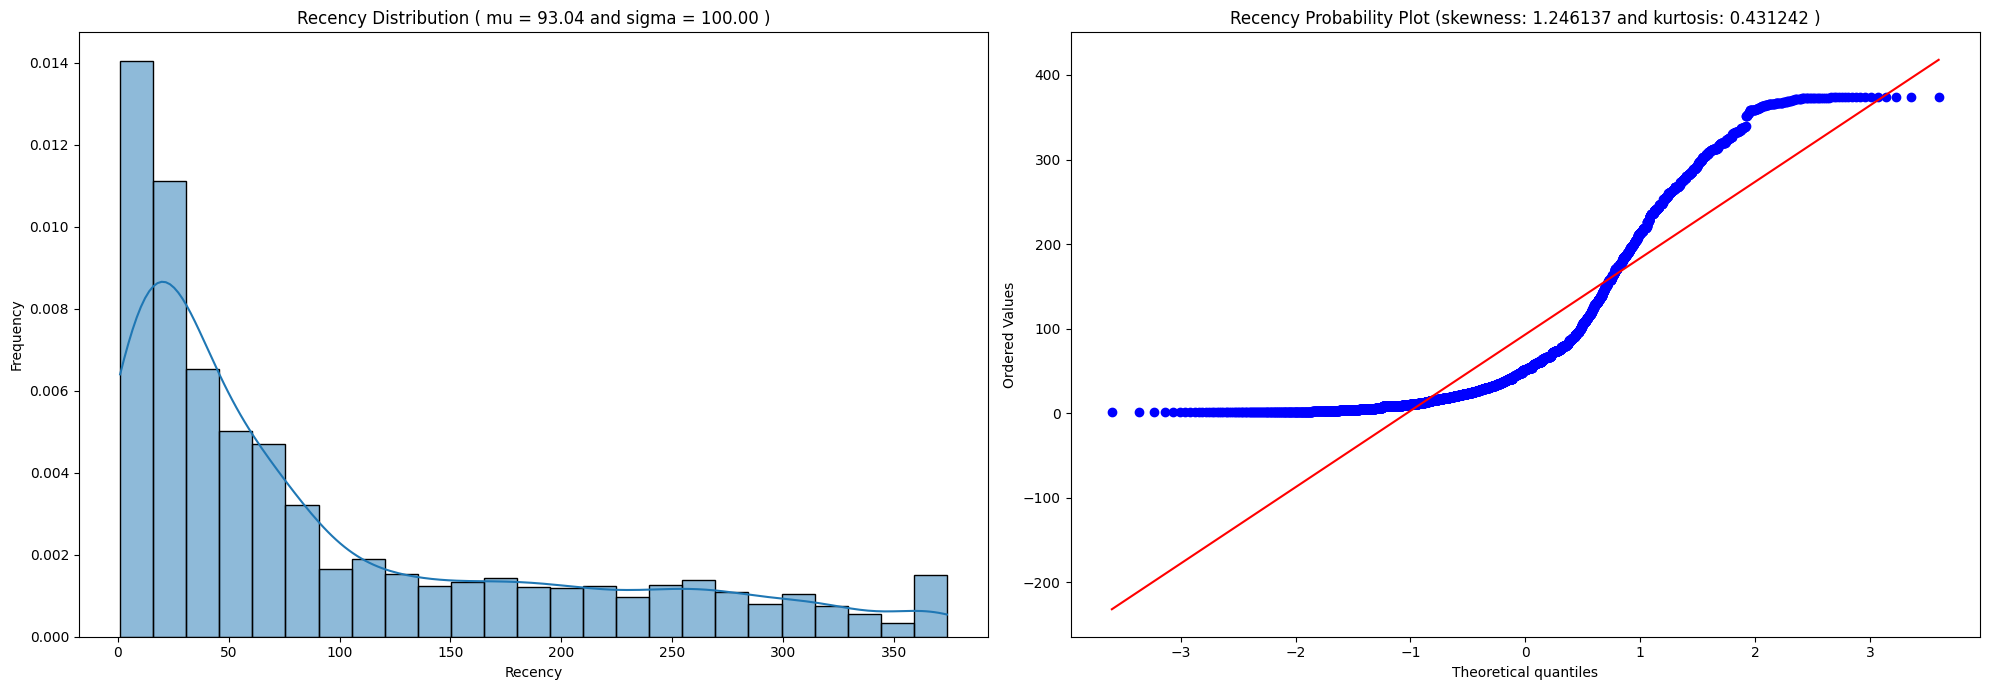

In [34]:
# Recency graphs using the dist_plot function
dist_plot(rfm_pd['Recency'], 'Recency')

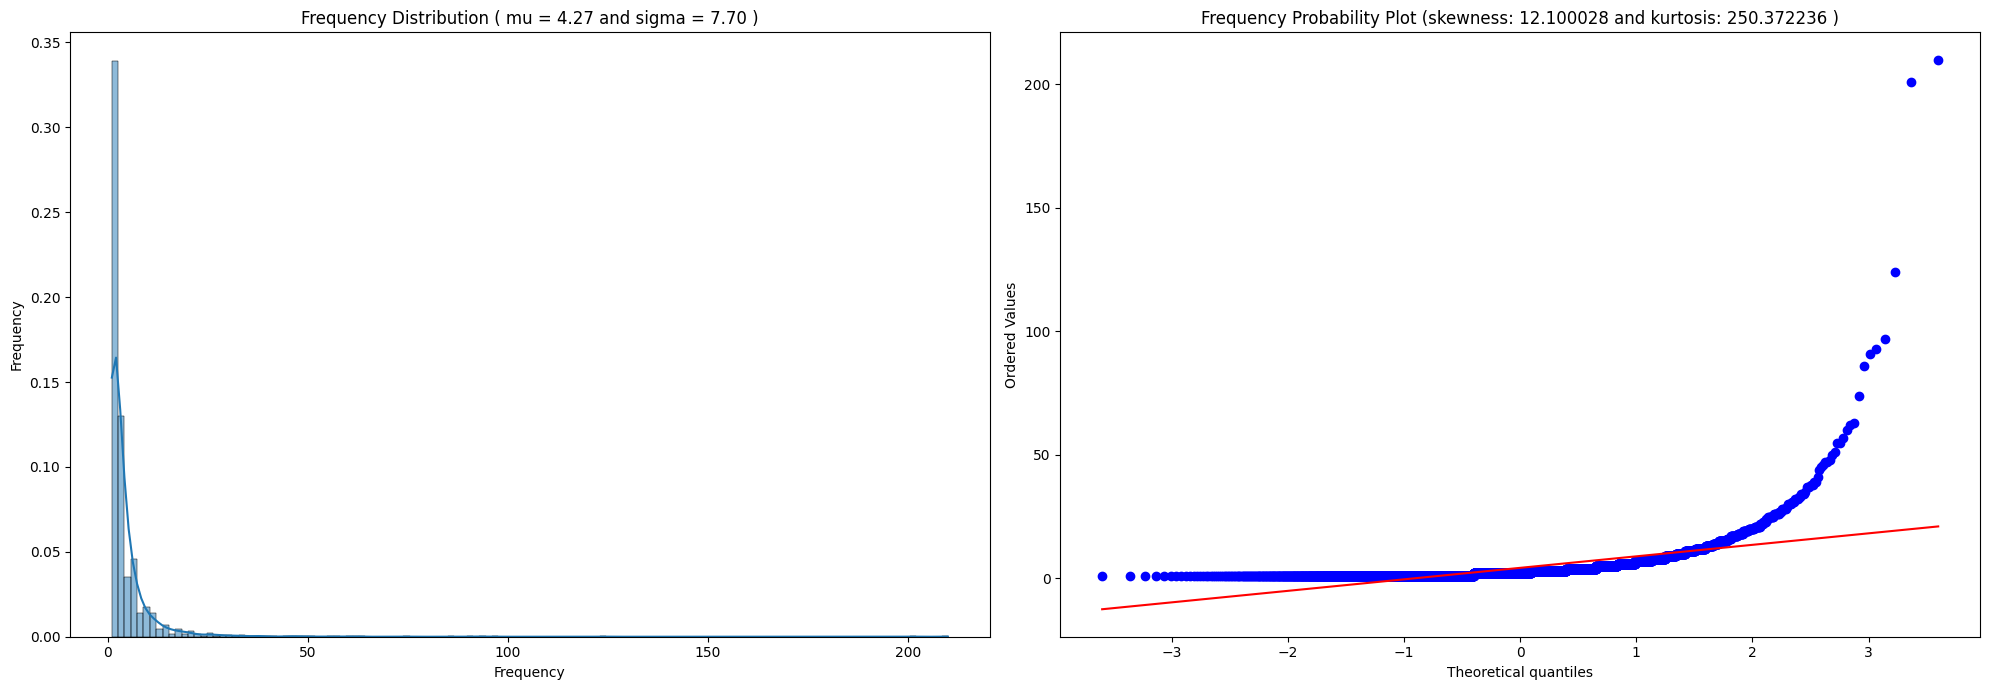

In [35]:
# Frequency graphs using the dist_plot function
dist_plot(rfm_pd['Frequency'], 'Frequency')

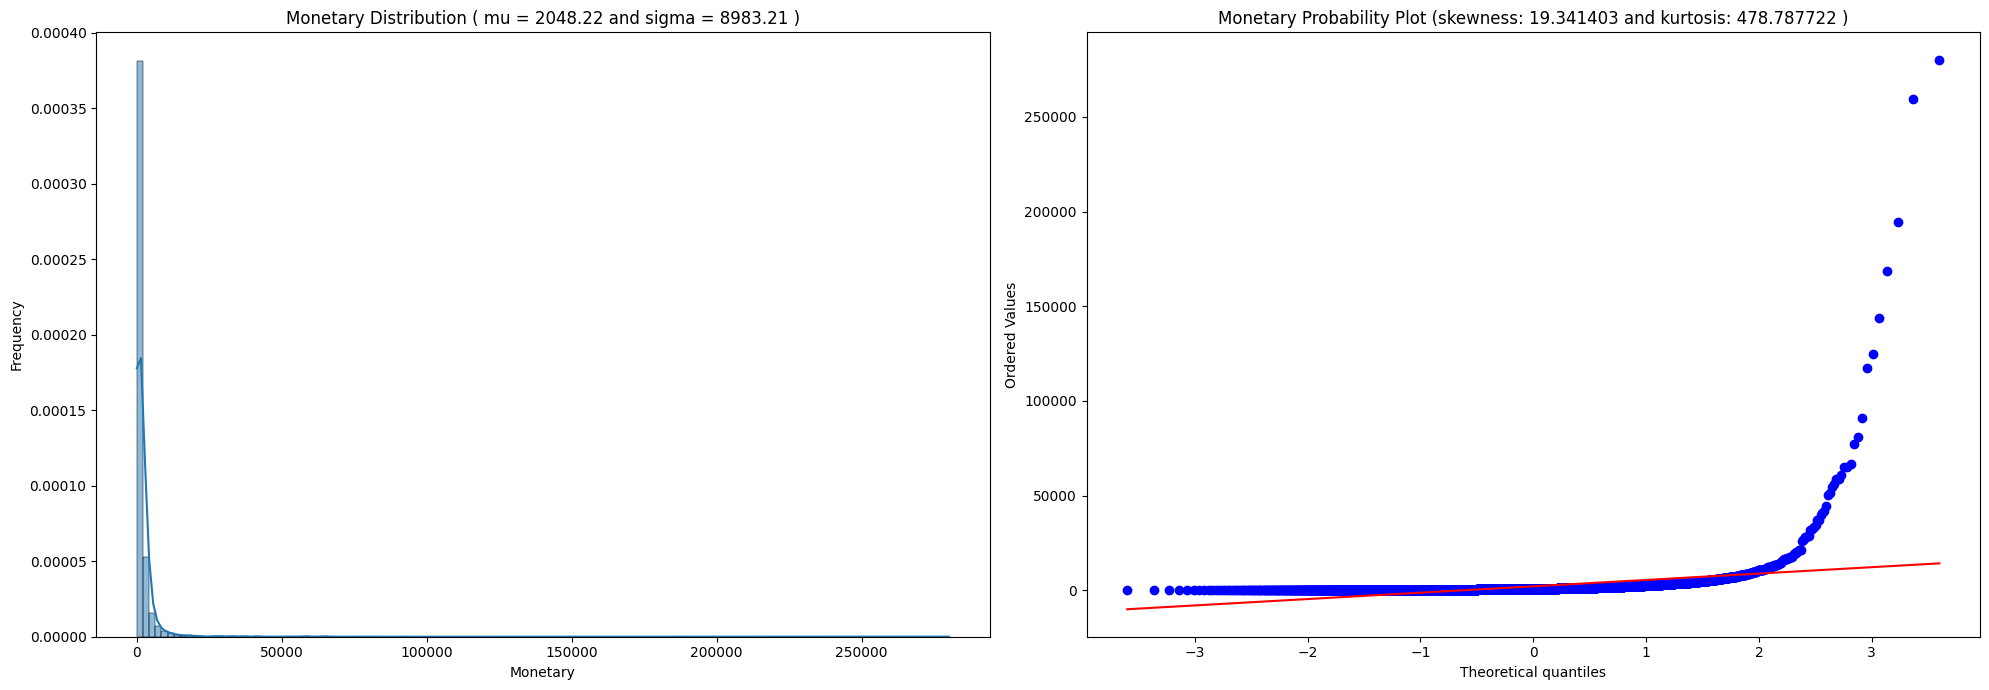

In [36]:
# Monetary graphs using the dist_plot function
dist_plot(rfm_pd['Monetary'], 'Monetary')

# Customer Segmentation Using Quantiles

In [37]:
# Calculate the quantiles for recency, frequency, and monetary
quantile_values = rfm_table.approxQuantile(['Recency', 'Frequency', 'Monetary'], [0.25, 0.5, 0.75], 0.01)
quantile = dict(zip(['Recency', 'Frequency', 'Monetary'], quantile_values))
print(quantile)

{'Recency': [18.0, 50.0, 138.0], 'Frequency': [1.0, 2.0, 5.0], 'Monetary': [303.96999999999997, 653.33, 1618.6899999999998]}


In [38]:
# Define the recency points function
# 0-25% = 4 / 25%-50% = 3 / 50%-75% = 2 / 75%-100% = 1
def recency_points(col, q):
    return (F.when(col <= q[0], 4)
             .when(col <= q[1], 3)
             .when(col <= q[2], 2)
             .otherwise(1))

# Define the monetary points function
# 0-25% = 1 / 25%-50% = 2 / 50%-75% = 3 / 75%-100% = 4
def freq_monetary_points(col, q):
    return (F.when(col <= q[0], 1)
             .when(col <= q[1], 2)
             .when(col <= q[2], 3)
             .otherwise(4))

In [39]:
# Apply RecencyPoint and MonetaryPoints function to Calculate Recency_Quartile, Frequency_Quartile, Monetary_Quartile
rfm_segment = (rfm_table
    .withColumn('Recency_Quartile', recency_points(F.col('Recency'), quantile['Recency']))
    .withColumn('Frequency_Quartile', freq_monetary_points(F.col('Frequency'), quantile['Frequency']))
    .withColumn('Monetary_Quartile', freq_monetary_points(F.col('Monetary'), quantile['Monetary'])))
rfm_segment.show(5)

+----------+-------+---------+-----------------+----------------+------------------+-----------------+
|CustomerID|Recency|Frequency|         Monetary|Recency_Quartile|Frequency_Quartile|Monetary_Quartile|
+----------+-------+---------+-----------------+----------------+------------------+-----------------+
|     17850|    373|       34|5391.210000000001|               1|                 4|                4|
|     17420|     51|        3|598.8299999999999|               2|                 3|                2|
|     15862|      9|        4|           832.88|               4|                 3|                3|
|     14045|    110|        4|          1659.75|               2|                 3|                4|
|     13694|      4|       50|         65039.62|               4|                 4|                4|
+----------+-------+---------+-----------------+----------------+------------------+-----------------+
only showing top 5 rows


RFM Classification

In [40]:
rfm_segment = rfm_segment.withColumn('RFMPoints',
    F.concat(F.col('Recency_Quartile').cast('string'),
             F.col('Frequency_Quartile').cast('string'),
             F.col('Monetary_Quartile').cast('string')))
rfm_segment.select('CustomerID', 'RFMPoints').show(5)

+----------+---------+
|CustomerID|RFMPoints|
+----------+---------+
|     17420|      232|
|     17850|      144|
|     16552|      122|
|     15350|      111|
|     12921|      444|
+----------+---------+
only showing top 5 rows


In [41]:
customer_dict = {'Best Customers':'444','Loyal Customers':'344','Big Spender':'334','Almost Lost':'244',
                  'Lost Customers':'144','Recent Customers':'443','Lost Cheap Customers':'122'}
dict_segment = dict(zip(customer_dict.values(), customer_dict.keys()))
mapping_expr = F.create_map([F.lit(x) for pair in dict_segment.items() for x in pair])

In [42]:
# Segment Customers based on RFM Points
rfm_segment = rfm_segment.withColumn('Segment', F.coalesce(mapping_expr[F.col('RFMPoints')], F.lit('others')))
rfm_segment.sample(0.1).show(10)

+----------+-------+---------+------------------+----------------+------------------+-----------------+---------+--------------------+
|CustomerID|Recency|Frequency|          Monetary|Recency_Quartile|Frequency_Quartile|Monetary_Quartile|RFMPoints|             Segment|
+----------+-------+---------+------------------+----------------+------------------+-----------------+---------+--------------------+
|     17420|     51|        3| 598.8299999999999|               2|                 3|                2|      232|              others|
|     13694|      4|       50|          65039.62|               4|                 4|                4|      444|      Best Customers|
|     17961|     22|       39|           1296.44|               3|                 4|                3|      343|              others|
|     18259|     25|        3|2338.6000000000004|               3|                 3|                4|      334|         Big Spender|
|     12652|    332|        1| 919.9800000000001|      

In [43]:
# Display Best Customers
best_customers = (rfm_segment.filter((F.col('Recency_Quartile') == 4) &
                                      (F.col('Frequency_Quartile') == 4) &
                                      (F.col('Monetary_Quartile') == 4))
                   .orderBy(F.asc('RFMPoints'), F.desc('Monetary')))
best_customers.show(5)

+----------+-------+---------+------------------+----------------+------------------+-----------------+---------+--------------+
|CustomerID|Recency|Frequency|          Monetary|Recency_Quartile|Frequency_Quartile|Monetary_Quartile|RFMPoints|       Segment|
+----------+-------+---------+------------------+----------------+------------------+-----------------+---------+--------------+
|     14646|      2|       74|280206.01999999996|               4|                 4|                4|      444|Best Customers|
|     18102|      1|       60|259657.30000000002|               4|                 4|                4|      444|Best Customers|
|     17450|      9|       46|194390.79000000004|               4|                 4|                4|      444|Best Customers|
|     14911|      2|      201|         143711.17|               4|                 4|                4|      444|Best Customers|
|     14156|     10|       55|117210.07999999997|               4|                 4|            

In [44]:
# Display Big Spenders
big_spenders = (rfm_segment.filter((F.col('Monetary_Quartile') == 4) & (F.col('RFMPoints') == '334'))
                 .orderBy(F.desc('Monetary')))
big_spenders.show(5)

+----------+-------+---------+-----------------+----------------+------------------+-----------------+---------+-----------+
|CustomerID|Recency|Frequency|         Monetary|Recency_Quartile|Frequency_Quartile|Monetary_Quartile|RFMPoints|    Segment|
+----------+-------+---------+-----------------+----------------+------------------+-----------------+---------+-----------+
|     12536|     44|        3|         12601.83|               3|                 3|                4|      334|Big Spender|
|     16126|     30|        4|          6287.77|               3|                 3|                4|      334|Big Spender|
|     13316|     38|        4|          5732.93|               3|                 3|                4|      334|Big Spender|
|     12539|     23|        4|          5568.35|               3|                 3|                4|      334|Big Spender|
|     16303|     26|        3|5360.629999999999|               3|                 3|                4|      334|Big Spender|


In [45]:
# Display Almost Lost whose recency is very low
almost_lost = rfm_segment.filter(F.col('RFMPoints') == '244').orderBy(F.desc('Monetary'))
almost_lost.show(5)

+----------+-------+---------+------------------+----------------+------------------+-----------------+---------+-----------+
|CustomerID|Recency|Frequency|          Monetary|Recency_Quartile|Frequency_Quartile|Monetary_Quartile|RFMPoints|    Segment|
+----------+-------+---------+------------------+----------------+------------------+-----------------+---------+-----------+
|     12744|     52|        7|21279.290000000005|               2|                 4|                4|      244|Almost Lost|
|     12939|     65|        8|           11581.8|               2|                 4|                4|      244|Almost Lost|
|     16180|    101|        8|          10254.18|               2|                 4|                4|      244|Almost Lost|
|     14952|     60|       11| 8099.489999999999|               2|                 4|                4|      244|Almost Lost|
|     16745|     87|       17| 7180.699999999999|               2|                 4|                4|      244|Almos

In [46]:
# Display Lost customers with low RFM all around
lost_cheap_customers = rfm_segment.filter(F.col('RFMPoints') == '122').orderBy(F.desc('Monetary'))
lost_cheap_customers.show(5)

+----------+-------+---------+-----------------+----------------+------------------+-----------------+---------+--------------------+
|CustomerID|Recency|Frequency|         Monetary|Recency_Quartile|Frequency_Quartile|Monetary_Quartile|RFMPoints|             Segment|
+----------+-------+---------+-----------------+----------------+------------------+-----------------+---------+--------------------+
|     18121|    150|        2|            653.3|               1|                 2|                2|      122|Lost Cheap Customers|
|     14548|    151|        2|            652.8|               1|                 2|                2|      122|Lost Cheap Customers|
|     15384|    170|        2|642.4099999999999|               1|                 2|                2|      122|Lost Cheap Customers|
|     18218|    212|        2|           641.92|               1|                 2|                2|      122|Lost Cheap Customers|
|     12365|    292|        2|641.3799999999999|              

In [47]:
# Display loyal customers whose purchase frequency is high
loyal_freq_customers = rfm_segment.filter(F.col('RFMPoints') == '344').orderBy(F.desc('Monetary'))
loyal_freq_customers.show(5)

+----------+-------+---------+------------------+----------------+------------------+-----------------+---------+---------------+
|CustomerID|Recency|Frequency|          Monetary|Recency_Quartile|Frequency_Quartile|Monetary_Quartile|RFMPoints|        Segment|
+----------+-------+---------+------------------+----------------+------------------+-----------------+---------+---------------+
|     12415|     25|       21|124914.52999999998|               3|                 4|                4|      344|Loyal Customers|
|     16029|     39|       63|          80850.84|               3|                 4|                4|      344|Loyal Customers|
|     12931|     22|       15|          42055.96|               3|                 4|                4|      344|Loyal Customers|
|     14680|     26|       16|28754.109999999997|               3|                 4|                4|      344|Loyal Customers|
|     12753|     23|        6|21429.389999999996|               3|                 4|     

In [48]:
# Display customers to retain: monetary and frequency was high but recency reduced quite a lot recently
almost_lost_recency = rfm_segment.filter(F.col('RFMPoints') == '244').orderBy(F.desc('Monetary'))
almost_lost_recency.show(5)

+----------+-------+---------+------------------+----------------+------------------+-----------------+---------+-----------+
|CustomerID|Recency|Frequency|          Monetary|Recency_Quartile|Frequency_Quartile|Monetary_Quartile|RFMPoints|    Segment|
+----------+-------+---------+------------------+----------------+------------------+-----------------+---------+-----------+
|     12744|     52|        7|21279.290000000005|               2|                 4|                4|      244|Almost Lost|
|     12939|     65|        8|           11581.8|               2|                 4|                4|      244|Almost Lost|
|     16180|    101|        8|          10254.18|               2|                 4|                4|      244|Almost Lost|
|     14952|     60|       11| 8099.489999999999|               2|                 4|                4|      244|Almost Lost|
|     16745|     87|       17| 7180.699999999999|               2|                 4|                4|      244|Almos

# RFM Distribution Visualization

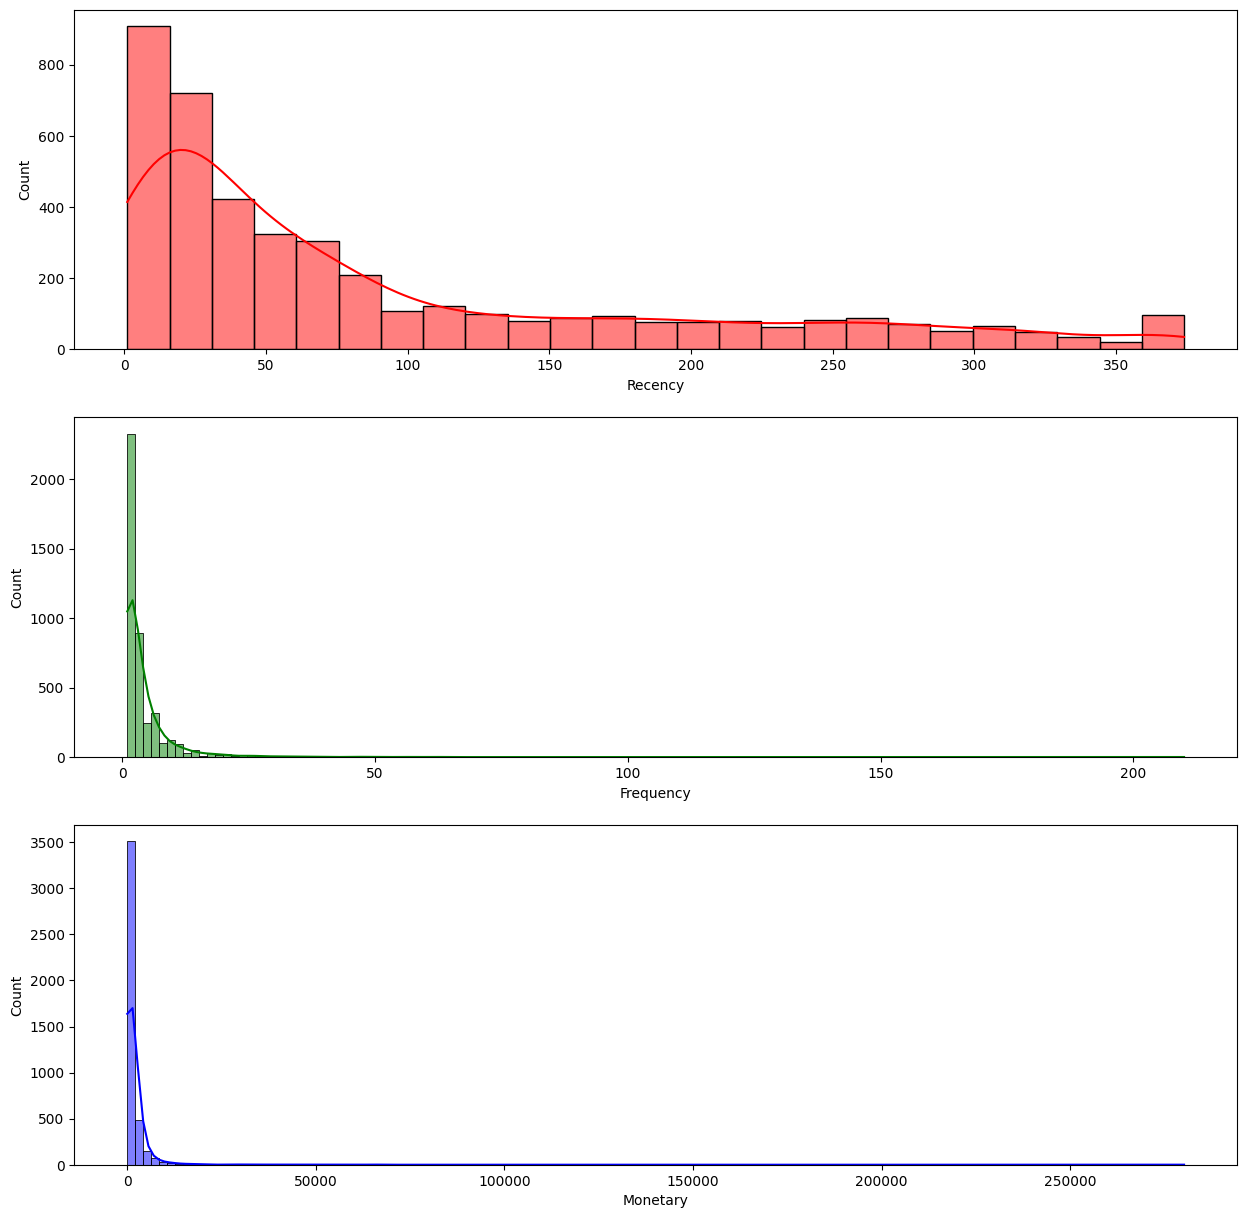

In [49]:
fig, axes = plt.subplots(3, 1, figsize=(15, 15))
sns.histplot(rfm_pd['Recency'], color='Red', ax=axes[0], kde=True)
sns.histplot(rfm_pd['Frequency'], color='Green', ax=axes[1], kde=True)
sns.histplot(rfm_pd['Monetary'], color='Blue', ax=axes[2], kde=True)
axes[0].set_xlabel('Recency')
axes[1].set_xlabel('Frequency')
axes[2].set_xlabel('Monetary')
plt.show()

In [50]:
rfm_table.describe().show()

26/07/31 19:46:51 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+-----------------+------------------+
|summary|        CustomerID|           Recency|        Frequency|          Monetary|
+-------+------------------+------------------+-----------------+------------------+
|  count|              4339|              4339|             4339|              4339|
|   mean|15299.936851809172|  93.0414842129523|4.271952062687255|2048.2159239456096|
| stddev|1721.8897579594216|100.00775734416366|7.705492771314827|  8984.24835166338|
|    min|             12346|                 1|                1|               0.0|
|    max|             18287|               374|              210|280206.01999999996|
+-------+------------------+------------------+-----------------+------------------+



In [51]:
# Shift Monetary and Recency to be strictly positive before log transforming
min_recency = rfm_table.agg(F.min('Recency')).first()[0]
min_monetary = rfm_table.agg(F.min('Monetary')).first()[0]

scaled_rfm = (rfm_table
    .withColumn('Recency', F.col('Recency') - F.lit(min_recency) + 1)
    .withColumn('Monetary', F.col('Monetary') - F.lit(min_monetary) + 1))
scaled_rfm.describe().show()

+-------+------------------+------------------+-----------------+------------------+
|summary|        CustomerID|           Recency|        Frequency|          Monetary|
+-------+------------------+------------------+-----------------+------------------+
|  count|              4339|              4339|             4339|              4339|
|   mean|15299.936851809172|  93.0414842129523|4.271952062687255|2049.2159239456096|
| stddev|1721.8897579594216|100.00775734416366|7.705492771314827|  8984.24835166338|
|    min|             12346|                 1|                1|               1.0|
|    max|             18287|               374|              210|280207.01999999996|
+-------+------------------+------------------+-----------------+------------------+



/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


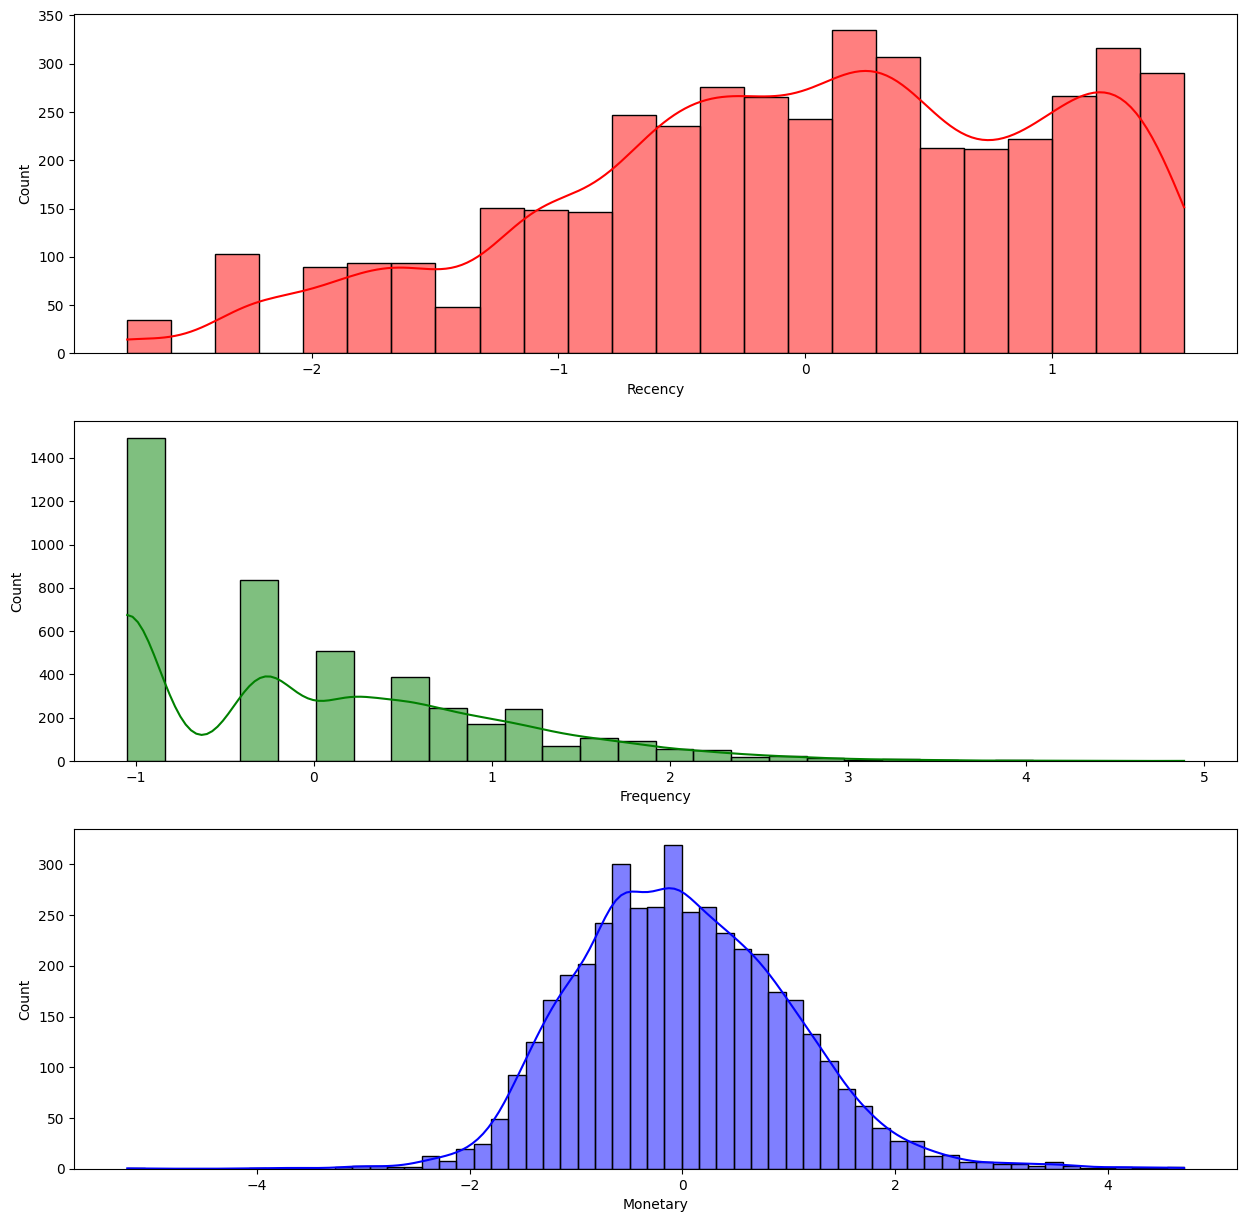

In [52]:
# Log transform and standardize Recency, Frequency, and Monetary
log_rfm = (scaled_rfm
    .withColumn('Recency', F.log('Recency'))
    .withColumn('Frequency', F.log('Frequency'))
    .withColumn('Monetary', F.log('Monetary')))

assembler = VectorAssembler(inputCols=['Recency', 'Frequency', 'Monetary'], outputCol='features')
assembled = assembler.transform(log_rfm)

scaler = StandardScaler(inputCol='features', outputCol='scaled_features', withMean=True, withStd=True)
scaler_model = scaler.fit(assembled)
normal_data = scaler_model.transform(assembled)

normal_pd = normal_data.select('CustomerID', 'scaled_features').toPandas()
normal_pd[['Recency', 'Frequency', 'Monetary']] = pd.DataFrame(normal_pd['scaled_features'].tolist(), index=normal_pd.index)

fig, axes = plt.subplots(3, 1, figsize=(15, 15))
sns.histplot(normal_pd['Recency'], color='Red', ax=axes[0], kde=True)
sns.histplot(normal_pd['Frequency'], color='Green', ax=axes[1], kde=True)
sns.histplot(normal_pd['Monetary'], color='Blue', ax=axes[2], kde=True)
axes[0].set_xlabel('Recency')
axes[1].set_xlabel('Frequency')
axes[2].set_xlabel('Monetary')
plt.show()

# Clustering Analysis

## Feature Vector

In [53]:
# Reuse the scaled log-transformed RFM features already assembled above
scaled_data = normal_data
scaled_data.select('CustomerID', 'scaled_features').show(5, truncate=False)

+----------+--------------------------------------------------------------+
|CustomerID|scaled_features                                               |
+----------+--------------------------------------------------------------+
|17420     |[0.09469965104547684,0.17127240846831238,-0.15083837082141002]|
|17850     |[1.5328391313314345,2.8661920740375977,1.588946498269843]     |
|16552     |[1.2231186546743376,-0.27881375671271724,-0.5109504724904711] |
|15350     |[1.5347742675458524,-1.0482411381707637,-1.4480875092931482]  |
|12921     |[-1.0828713308733557,2.9600549237729257,2.479197218444047]    |
+----------+--------------------------------------------------------------+
only showing top 5 rows


## Finding the Number of Clusters (Elbow Method)

In [54]:
# Fit KMeans for a range of cluster counts and track the within-cluster sum of squares (WSSSE)
ks = range(2, 10)
costs = []

for k in ks:
    km = KMeans(featuresCol='scaled_features', k=k, seed=42)
    model = km.fit(scaled_data)
    costs.append(model.summary.trainingCost)

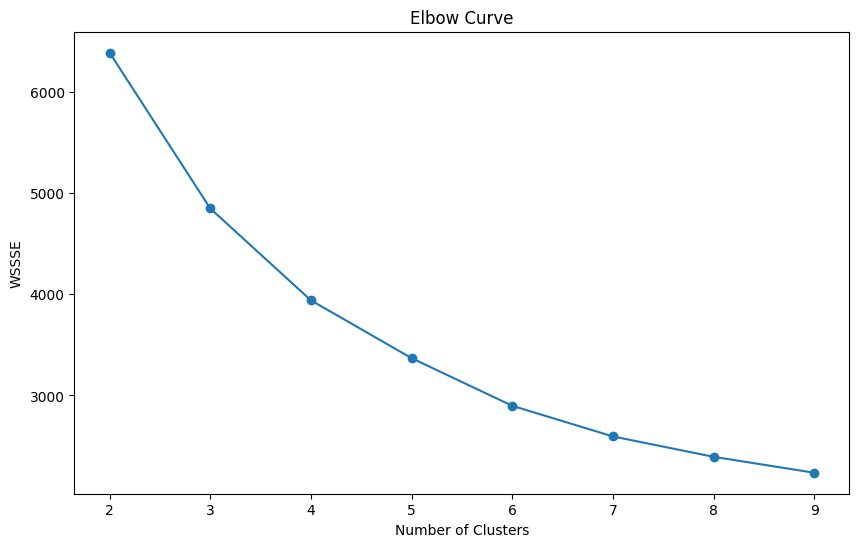

In [55]:
# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(list(ks), costs, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WSSSE')
plt.title('Elbow Curve')
plt.show()

## Building the K-Means Clustering Model

In [56]:
# Fit the final KMeans model
final_k = 4
kmeans = KMeans(featuresCol='scaled_features', k=final_k, seed=42)
kmeans_model = kmeans.fit(scaled_data)

## Making Predictions

In [57]:
preds = kmeans_model.transform(scaled_data)
preds.select('CustomerID', 'Recency', 'Frequency', 'Monetary', 'prediction').show(10)

+----------+------------------+------------------+------------------+----------+
|CustomerID|           Recency|         Frequency|          Monetary|prediction|
+----------+------------------+------------------+------------------+----------+
|     17850| 5.921578419643816|3.5263605246161616|  8.59271059842128|         3|
|     17420|3.9318256327243257|1.0986122886681096|6.3966462817363405|         3|
|     15862|2.1972245773362196|1.3862943611198906| 6.726089507114236|         2|
|     14045| 4.700480365792417|1.3862943611198906| 7.415024586545351|         3|
|     13694|1.3862943611198906| 3.912023005428146|11.082767276771584|         0|
|     16552| 5.493061443340548|0.6931471805599453|5.9420904624901825|         1|
|     17572| 4.276666119016055|1.3862943611198906| 5.428248536140067|         3|
|     15350| 5.924255797414532|               0.0| 4.759177998467439|         1|
|     12921| 2.302585092994046|3.6109179126442243| 9.716440246960428|         0|
|     14496|5.74300318780948

In [58]:
# Evaluate clustering quality using the silhouette score
evaluator = ClusteringEvaluator(predictionCol='prediction', featuresCol='scaled_features', metricName='silhouette')
silhouette = evaluator.evaluate(preds)
print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.4939


# Cluster Analysis

In [59]:
# Average Recency, Frequency, and Monetary per cluster
cluster_profile = (preds.groupBy('prediction')
    .agg(F.mean('Recency').alias('avg_recency'),
         F.mean('Frequency').alias('avg_frequency'),
         F.mean('Monetary').alias('avg_monetary'),
         F.count('*').alias('num_customers'))
    .orderBy('prediction'))
cluster_profile.show()

+----------+------------------+-------------------+-----------------+-------------+
|prediction|       avg_recency|      avg_frequency|     avg_monetary|num_customers|
+----------+------------------+-------------------+-----------------+-------------+
|         0|1.9963526992052487| 2.3032874484470818|8.268396496023007|          763|
|         1|5.1133355408489125|0.17774860785126792|5.584836138704098|         1472|
|         2|2.8678152162132236| 0.4860435263744554|5.892848763058158|          829|
|         3|3.9719358077713824|  1.314053780177794|7.189291142456802|         1275|
+----------+------------------+-------------------+-----------------+-------------+



/opt/anaconda3/envs/py-tf-torch-env/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


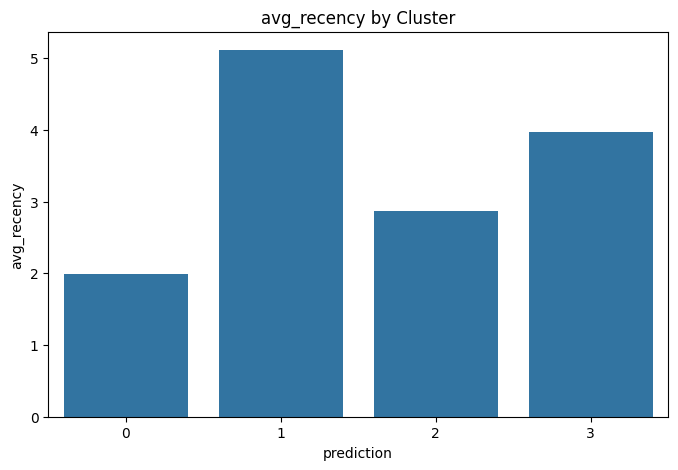

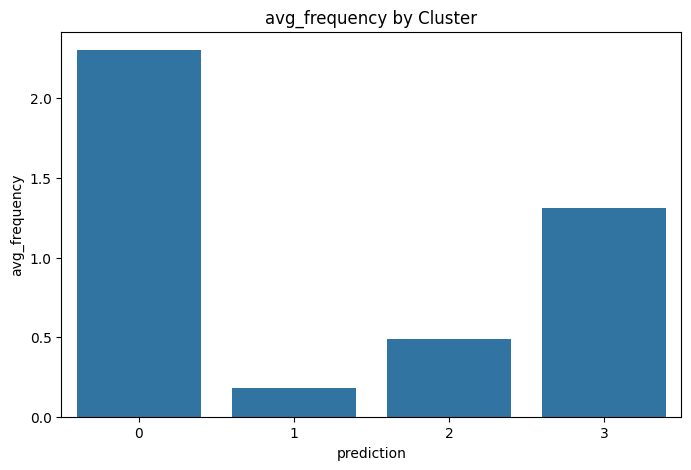

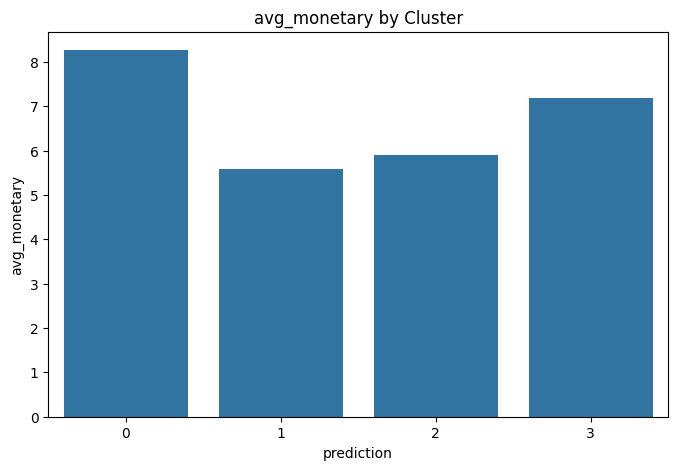

In [60]:
profile_pd = cluster_profile.toPandas()
rfm_columns = ['avg_recency', 'avg_frequency', 'avg_monetary']

for metric in rfm_columns:
    plt.figure(figsize=(8, 5))
    sns.barplot(x='prediction', y=metric, data=profile_pd)
    plt.title(f'{metric} by Cluster')
    plt.show()

In [61]:
spark.stop()